In [2]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.partial_sc import partial_sc


In [3]:
widthD = 10
widthF = 1
widthP = 40

X, Y = widthD+widthF+widthP+widthF+widthD, 200
lattice = Lattice(X, Y)

t = 1
T = 0.001

muD = 0.0 * t
muP = 1.8 * t
muF = 1.4 * t

mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:widthD + widthF + widthP] = muP
mu[widthD + widthF + widthP:widthD + widthF + widthP + widthF] = muF
mu[widthD + widthF + widthP + widthF:widthD + widthF + widthP + widthF + widthD] = muD

h0 = 0.9 * t
h = np.zeros_like(mu)
h[widthD:widthD + widthF] = h0
h[widthD + widthF + widthP + widthF-1] = -h0


U0 = 0.0 * t
U = U0 * np.ones(lattice.X)
U[widthD:] = 0
U[widthD-1] = U0/2

V0 = 4 * t
V = V0 * np.ones(lattice.X)
V[widthD:-widthD] = 0
V[widthD-1] = V0/2
V[-widthD] = V0/2


V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0
V_prime[widthF+widthD+widthP:] = 0
V_prime[widthF+widthD] = V_prime0/2
V_prime[widthF+widthD+widthP-1] = V_prime0/2

# bulk p-wave F=0.018

In [4]:
from scripts.utils import is_hermitian

H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.23, 0.23, -0.23, -0.23],
                Fuu_init=[0.01, -0.01, 0.01j, -0.01j],
                Fdd_init=[0.01, -0.01, 0.01j, -0.01j],
                hx=h)

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_kindep()))

True
True
True


In [5]:
# F, Fuu, Fdd = H.get_correlations()

# x = np.arange(0, widthD + widthF + widthP+ widthF + widthD)

# fig, axs = plt.subplots(1, 1, figsize=(8, 6))
# axs.set_title(f"V/t = 5, V'/t= 1.5, T/t={T}, hx/t={h0}")

# axs.axvline(widthD, color='black', linestyle='--')
# axs.axvline(widthD-1, color='black', linestyle='--')
# axs.axvline(widthD + widthF + widthP, color='black', linestyle='--')
# axs.axvline(widthD + widthF + widthP+1, color='black', linestyle='--')

# # axs.plot(x, np.real(H.F0), label="onsite")
# # axs.plot(x, np.real(F.dwave), label="F.dwave")
# # axs.plot(x, np.real(F.swave), label="F.swave")

# axs.plot(x, np.real(F.px), label="ud:p_x-wave")
# axs.plot(x, np.imag(F.py), "--", label="ud:p_y-wave")

# # axs.plot(x, np.real(Fuu.px-Fdd.px)/2, label="uu:p_x-wave")
# # axs.plot(x, np.imag(Fuu.py+Fdd.py)/2, "--", label="uu:p_y-wave")
# axs.set_xlabel("x", fontsize=15)

# axs.legend()
# plt.show()

In [11]:
from scripts.self_consistency import bdg_sc

fixed_sites = (V_prime == 0)
fixed_syms = ["F_xplus", "F_xmin", "F_yplus", "F_ymin"]
partial_sc(H, temperature=T,
           fixed_sites=fixed_sites,
           fixed_syms=fixed_syms,
           atol=1e-6, rtol=1e-3, maxiter=500, 
           verbose=True)
# bdg_sc(H, temperature=T,
#            atol=1e-3, rtol=1e-1, maxiter=500, 
#            verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 1.7106184042171605e-07
Relative error: 0.00025830182349538284
Average old: (0.0001933100988974757-1.0900888474226206e-09j)
Average: (0.00019330589105981627-1.0902178204532104e-09j)
F_xplus:
Absolute error: 1.0979163218293242e-07
Relative error: 0.009001533960289647
Average old: (0.07145106382104527+3.244888525530054e-10j)
Average: (0.07145107135552789+3.2467855743510995e-10j)
F_xmin:
Absolute error: 1.1260952890812016e-07
Relative error: 0.005077995147923911
Average old: (0.07191372347226643+6.037232456235038e-10j)
Average: (0.07191373141466681+6.037966178876946e-10j)
F_yplus:
Absolute error: 2.8535036580802554e-07
Relative error: 0.0003648003173340956
Average old: (-0.07480795968169504+3.9030149829401e-06j)
Average: (-0.07480795889075721+3.903987629721431e-06j)
F_ymin:
Absolute error: 2.8534747697372155e-07
Relative error: 0.00036480249848981036
Average old: (-0.07480793662370246-3.903098044575366e-06j)
Average: (-0.07480793583425303-3.9040707351990424e-06j)
Fuu_xp

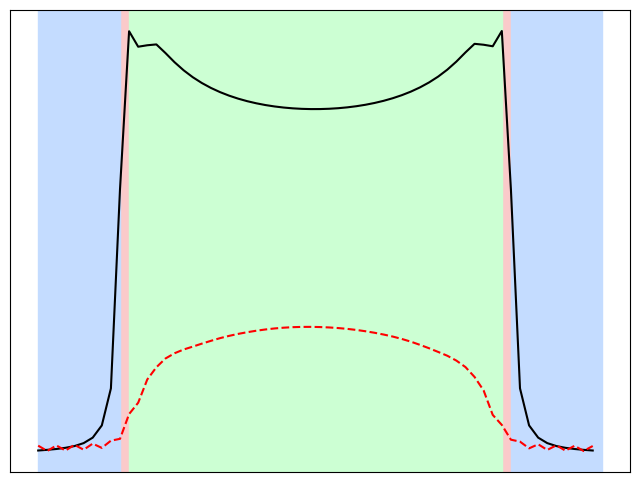

In [17]:
x = np.arange(0, widthD + widthF + widthP+ widthF + widthD)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
# axs.set_title(f"V/t = {V0}, V'/t={V_prime0}, T/t={T}, hx/t={h0}")

axs.axvspan(widthD - 1, widthD, color='#FACACA')
axs.axvspan(0, widthD - 1, color='#C4DCFF')

axs.axvspan(widthD + widthF + widthP, widthD + widthF + widthP+1, color='#FACACA')
axs.axvspan(widthD + widthF-1, widthD + widthF + widthP, color='#CCFFD3')
axs.axvspan(widthD + widthF + widthP + widthF,  widthD + widthF + widthP+ widthF + widthD, color='#C4DCFF')

# axs.plot(x, np.real(H.F0), label="onsite")
# axs.plot(x, np.real(F.dwave), label="F.dwave")
# axs.plot(x, np.real(F.swave), label="F.swave")

# axs.plot(x, np.real(F.px), label="ud:p_x-wave")
# axs.plot(x, np.imag(F.py), "--", label="ud:p_y-wave")

axs.plot(x, np.real(Fuu.px-Fdd.px)/2, label="uu:p_x-wave", color='black')
axs.plot(x, np.imag(Fuu.py+Fdd.py)/2, "--", label="uu:p_y-wave", color='red')
# axs.set_xlabel("x", fontsize=15)

# axs.set_yticks([0.0, 0.01, 0.02, 0.03, 0.04])
axs.set_xticks([])
axs.set_yticks([])

# axs.tick_params(axis='both', labelsize=12)

# axs.set_ylim(0.0, 0.04)
# axs.set_xlim(0.0, 61)

# axs.axvline(x[int(widthD+widthF+widthP/2)])
# axs.legend(fontsize=16, loc='center')
# print(np.real(Fuu.px-Fdd.px)[int(widthD+widthF+widthP/2)]/2)
# print()
plt.savefig("../figures/DFPFD.svg", bbox_inches='tight')
plt.show()

In [8]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.010, 0.110 + 1e-12, 0.001),
    np.arange(0.1105, 0.1500 + 1e-12, 0.0005),
    np.arange(0.141, 0.200 + 1e-12, 0.001),
])  # 240 temps total

print(len(temps))

250
